# Class 4 — Implied Volatility and the Transition to Machine Learning

VIX, comparison of historical/range/conditional/implied volatility, and saving the feature data for later ML notebooks.

**Teaching note.** This notebook is intended to be run from top to bottom. Reusable data-loading and helper routines are in `course_tools.py`.


## Setup


In [2]:
# If needed:
# %pip install yfinance arch scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import course_tools_general as ctg


# Download data for any ticker directly into your target variable
spx = ctg.load_prices(ticker="^GSPC", start="1990-01-01")
spx.head()

print(f"S&P 500 sample: {spx.index.min().date()} to {spx.index.max().date()}")

# These range measures were introduced in Class 2.
# Reuse them here without requiring the Class 2 kernel to remain open.
gk20 = ctg.garman_klass_rolling(spx, window=20).to_numpy()
ok20 = ctg.ok_rolling(spx, window=20).to_numpy()




# GJR-GARCH-in-Mean was taught in Class 3.  Re-estimate it here quietly
# so this notebook can be run independently after a kernel restart.
gjr_daily_vol, garch_m_lev_results = ctg.fit_gjr_garch_in_mean_volatility(spx, nlags=5)

vol_df = pd.DataFrame(index=spx.index)
vol_df["GJR_GARCH_M"] = gjr_daily_vol


S&P 500 sample: 1990-01-02 to 2026-08-28


## Implied Volatility from Option Prices
- Since 1990 the CBOE (Chicago Board Options Exchange) published the implied volatility VIX measure
- It is derived from options pricing
- An option is a contract with the right (but not the obligation) to buy or see to buy or sell an asset at an agreed strick price at a future date.
- Naturally the price of the option contract depends on the length of the contract, the risk free interest rate for discounting expected future profits, the specific strike price and the volatility in the market.  Obviously higher volatility would imply higher prices for the options contracts.
- We do not observe the volatility used in the pricing of the contracts. But we do observe the risk free rate, the strike price in the contracts, and the length of the contract.
- The CME "inverts" a widely used option pricing model to find the $\textbf{implied volatility}$ given these observables.



### The Black-Scholes Foundation

The Black-Scholes (1973) formula prices a European call option as:

$$C = S_0 \cdot N(d_1) - K e^{-rT} \cdot N(d_2)$$

where:
- $C$ = call option price
- $S_0$ = current asset price
- $K$ = strike price
- $r$ = risk-free interest rate
- $T$ = time to expiration
- $N(\cdot)$ = cumulative standard normal distribution

with auxiliary terms:

$$d_1 = \frac{\ln(S_0/K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

The only **unobservable** input is $\sigma$ — the volatility of the underlying asset. Everything else ($S_0$, $K$, $r$, $T$) is directly observed in the market.

---

### The Inversion Problem

Black-Scholes maps inputs to a price, but the market *gives* you the price, so you run it backwards:

$$C^{\text{market}} = \text{BS}(\sigma) \implies \hat{\sigma}_{\text{implied}} = \text{BS}^{-1}(C^{\text{market}})$$

There is no closed-form inverse, so this is solved numerically via **Newton-Raphson iteration**, updating at each step using the option's vega $\mathcal{V} = \frac{\partial C}{\partial \sigma}$:

$$\sigma_{n+1} = \sigma_n - \frac{\text{BS}(\sigma_n) - C^{\text{market}}}{\mathcal{V}(\sigma_n)}$$

---

### What the VIX Actually Measures

The VIX aggregates implied volatilities across a wide range of strikes $K_i$ on S&P 500 options, targeting a 30-day horizon. It is expressed as an annualized percentage, so implied monthly volatility is approximately:

$$\sigma_{\text{monthly}} \approx \frac{\text{VIX}}{\sqrt{12}}$$

For example, $\text{VIX} = 20$ implies roughly $\frac{20}{\sqrt{12}} \approx 5.8\%$ over the next month.

Since 2003, the CBOE uses a model-free formula:

$$\sigma^2 = \frac{2}{T} \sum_i \frac{\Delta K_i}{K_i^2} e^{rT} Q(K_i) - \frac{1}{T}\left(\frac{F}{K_0} - 1\right)^2$$

where $Q(K_i)$ is the option mid-price at strike $K_i$, $F$ is the forward index level, and $K_0$ is the first strike below $F$.

---

### The Variance Risk Premium

Implied volatility $\hat{\sigma}_{\text{implied}}$ tends to exceed realized volatility $\sigma_{\text{realized}}$ on average. This gap is the **variance risk premium (VRP)**:

$$\text{VRP} = \hat{\sigma}^2_{\text{implied}} - \sigma^2_{\text{realized}} > 0$$

---

### The Volatility Smile

Under Black-Scholes, $\hat{\sigma}_{\text{implied}}$ should be constant across all strikes $K$. Empirically, plotting $\hat{\sigma}_{\text{implied}}$ against moneyness $K/S_0$ reveals a skew:

$$\hat{\sigma}_{\text{implied}}(K) \text{ is decreasing in } K \text{ for equity markets}$$

Deep out-of-the-money puts carry higher implied vol than at-the-money options, reflecting demand for crash protection beyond what the lognormal distribution in Black-Scholes accommodates.


In [4]:
vix = ctg.load_prices("^VIX", start="1990-01-01")

vix['VIX'] = vix['Close']

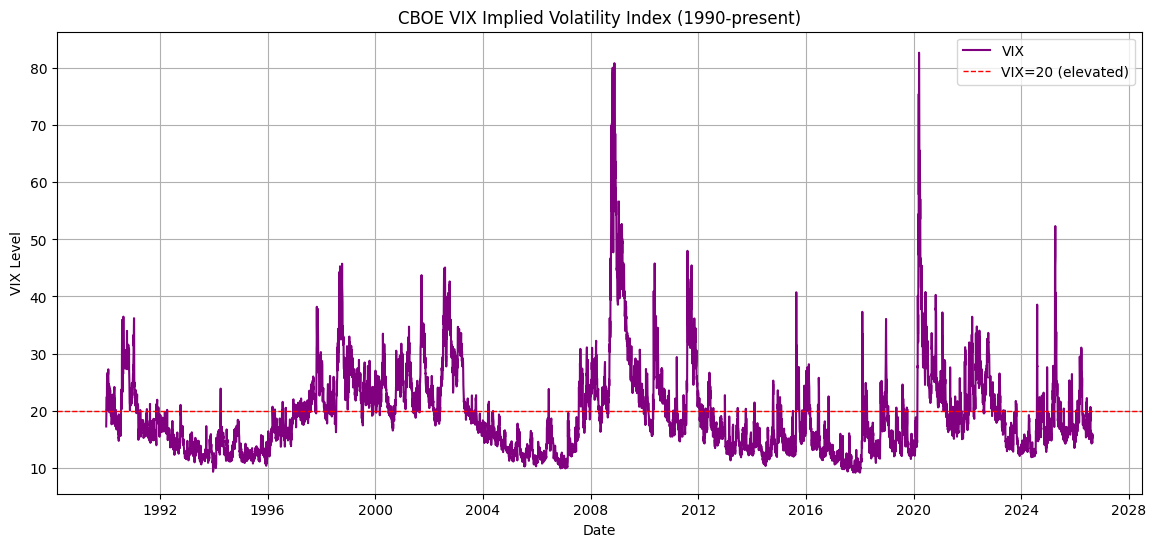

In [5]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(vix.index, vix['Close'], label='VIX', color='purple', linewidth=1.5)
plt.axhline(y=20, color='red', linestyle='dashed', linewidth=1.0, label='VIX=20 (elevated)')
plt.title('CBOE VIX Implied Volatility Index (1990-present)')
plt.xlabel('Date')
plt.ylabel('VIX Level')
plt.legend()
plt.grid(True)
plt.savefig("vix.png", dpi=150, bbox_inches='tight')
plt.show()

Sample: 1990-01-30 to 2026-08-27
Observations: 9211

       Historical_Vol   GK_Vol  GARCH_Vol    Close     High      Low     Open  \
count         9211.00  9211.00    9211.00  9211.00  9211.00  9211.00  9211.00   
mean            15.38    12.16      15.27    19.43    20.36    18.76    19.53   
std              9.58     6.55       8.96     7.74     8.29     7.29     7.81   
min              3.28     3.39       6.75     9.14     9.31     8.56     9.01   
25%              9.64     7.97       9.89    13.98    14.64    13.51    14.01   
50%             13.09    10.35      12.69    17.58    18.33    16.99    17.65   
75%             18.25    14.16      17.66    22.68    23.69    22.01    22.86   
max             97.90    68.37     117.34    82.69    89.53    72.76    82.69   

       Volume  Log_Close  Log_Open  Log_High  Log_Low   Return      VIX  
count  9211.0    9211.00   9211.00   9211.00  9211.00  9211.00  9211.00  
mean      0.0       2.90      2.91      2.95     2.87    -0.00    19.

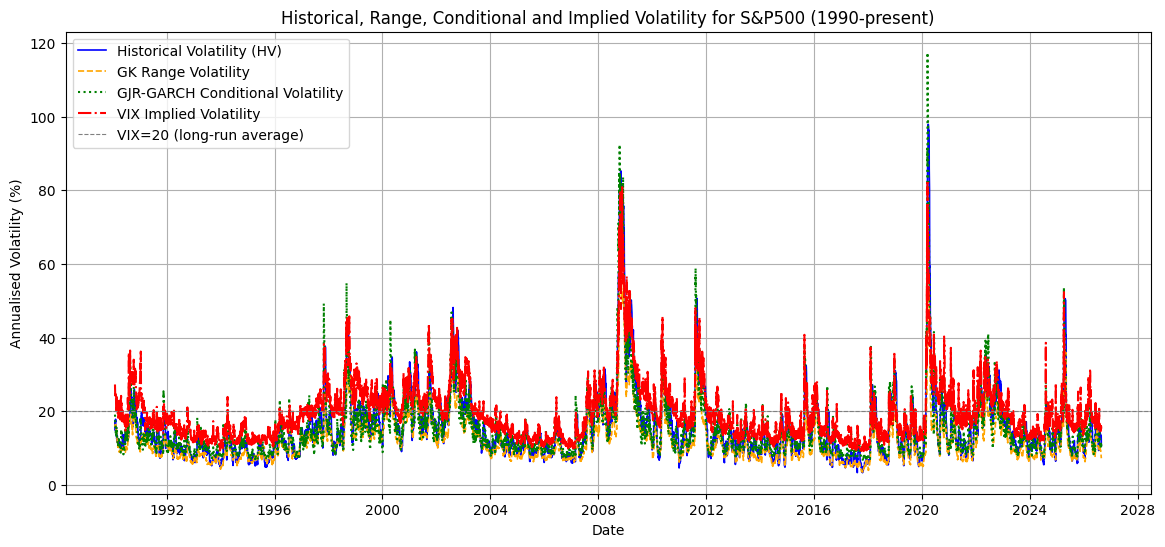

In [7]:

# -----------------------------
# 2. Annualise the three measures
# convert daily log-return units to annualised percentage
# -----------------------------
annual_factor = np.sqrt(252) * 100

ann_df = pd.DataFrame(index=spx.index)
ann_df['Historical_Vol'] = spx['Return'].rolling(20).std()  * annual_factor
ann_df['GK_Vol']         = pd.Series(gk20, index=spx.index) * annual_factor
ann_df['GARCH_Vol']      = vol_df['GJR_GARCH_M']            * annual_factor

# GJR_GARCH_M was already divided by 100 earlier so multiply back
# to get daily vol, then annualise
ann_df['GARCH_Vol']      = vol_df['GJR_GARCH_M'] *  annual_factor

# -----------------------------
# 3. Merge on common dates (1990 onward)
# -----------------------------
ann_df = ann_df.join(vix, how='inner')
ann_df = ann_df['1990':].dropna()

print(f"Sample: {ann_df.index[0].date()} to {ann_df.index[-1].date()}")
print(f"Observations: {len(ann_df)}")
print()
print(ann_df.describe().round(2))

# -----------------------------
# 4. Plot
# -----------------------------
plt.figure(figsize=(14, 6))

plt.plot(ann_df.index, ann_df['Historical_Vol'],
         label='Historical Volatility (HV)',
         linestyle='solid',   linewidth=1.2, color='blue')

plt.plot(ann_df.index, ann_df['GK_Vol'],
         label='GK Range Volatility',
         linestyle='dashed',  linewidth=1.2, color='orange')

plt.plot(ann_df.index, ann_df['GARCH_Vol'],
         label='GJR-GARCH Conditional Volatility',
         linestyle='dotted',  linewidth=1.5, color='green')

plt.plot(ann_df.index, ann_df['VIX'],
         label='VIX Implied Volatility',
         linestyle='dashdot', linewidth=1.5, color='red')

plt.axhline(y=20, color='grey', linestyle='dashed',
            linewidth=0.8, label='VIX=20 (long-run average)')

plt.title('Historical, Range, Conditional and Implied Volatility for S&P500 (1990-present)')
plt.xlabel('Date')
plt.ylabel('Annualised Volatility (%)')
plt.legend()
plt.grid(True)
plt.savefig("vol_comparison_annualised.png", dpi=150, bbox_inches='tight')
plt.show()

## Comparing Four Measures of S&P 500 Volatility (1990-present)

The chart above plots four distinct measures of stock market volatility, 
all converted to annualised percentage units for direct comparison.

### Key Observations

**1. VIX leads the other measures at crisis points**
The VIX (red) spikes before or simultaneously with the realised measures 
at every major crisis. This reflects the forward-looking nature of implied 
volatility — options markets price in fear before it shows up in returns.

**2. VIX stays elevated longer after crises**
After the GFC peak in 2008-09, VIX remains high well into 2012 while 
Historical and GK volatility drift back down faster. The market remained 
fearful even as actual volatility subsided. This gap between implied and 
realised volatility is known as the **variance risk premium** — investors 
systematically overpay for volatility insurance.

**3. GARCH has the sharpest spikes**
The GJR-GARCH conditional volatility (green) peaks highest at the GFC 
(~90%) and COVID (~115%), even exceeding VIX at those moments. This 
reflects GARCH's volatility clustering property — once a large shock hits, 
the model reacts very rapidly.

**4. GK Range Volatility is the smoothest and most conservative**
The Garman-Klass range estimator (orange) sits consistently below the 
other measures. By using intraday high-low information it filters out 
some of the close-to-close noise that inflates the other measures.

**5. The 2012-2019 low-volatility regime**
All four measures cluster together below 20% for most of this period — 
an unusually long calm that itself became a topic of academic research 
and was abruptly ended by COVID in early 2020.

### The Key Insight for Machine Learning

Since the four measures behave differently — especially around crises 
and in calm periods — no single measure dominates all others at all times. 
This motivates including **all four as features** in a machine learning model 
and letting the algorithm determine which measure contains the most 
useful predictive information in different market regimes.

## Comparing Range-Based and Return-Based Volatility Measures

- The comparison of the rolling standard deviation, the GK range-based volatility measure, and the GJR-GARCH conditional volatility estimate reveals several interesting features of financial market volatility.

- First, the rolling volatility and GJR-GARCH volatility measures display remarkably similar behavior over time. Their long-run averages are nearly identical across decades, and both measures identify the same major periods of market stress. This result is not surprising since both measures are based primarily on closing returns.

- By contrast, the GK range-based volatility measure assigns substantially higher volatility to the 1960s and 1970s than either the rolling standard deviation or the GJR-GARCH estimate.



- The higher values of the GK volatility measure in the 1960s and 1970s arise because the estimator uses intraday information through the high-low price range,

$$
\ln\left(\frac{H_t}{L_t}\right),
$$

- The rolling standard deviation and GARCH models use only closing returns.


- These results suggest that intraday market uncertainty was particularly important during the 1970s.

- Several major economic events may help explain this pattern:

    - Collapse of the Bretton Woods fixed exchange rate system.
    - First Oil Shock of 1973–1974.
    - Second Oil Shock of 1979.
    - High and volatile inflation.
    - Large fluctuations in interest rates.
    - Recessions and financial market instability.
    - Increased uncertainty regarding monetary policy.

- These events generated large intraday swings in asset prices that were captured by the high-low range but were not always reflected in close-to-close returns.

- Consequently, the OK range-based estimator may contain information about market uncertainty that is not fully captured by rolling standard deviations or GARCH-type models.

### Implications for Machine Learning

- If all volatility measures produced identical results, there would be little reason to include more than one measure in a forecasting model.
- The fact that the range-based estimator behaves differently during certain periods suggests that it may contain incremental information about market conditions.

- This observation motivates the use of multiple volatility measures as features in machine learning models.

- For example, the feature vector may include

    - Lagged returns,
    - Rolling volatility,
    - OK range volatility,
    - GARCH volatility,
    - GJR-GARCH volatility,
    - Trading volume,
    - VIX,
    - Interest rates,
    - Macroeconomic indicators.

- Machine learning algorithms can then determine whether the information contained in these alternative measures improves forecasting performance.

- Rather than asking which volatility measure is "correct," a machine learning approach asks whether each measure contributes useful predictive information for forecasting future returns, future volatility, or portfolio performance.

# From Volatility Modeling to Machine Learning

- Up to this point, we have focused on measuring, modeling, and forecasting financial market volatility. The next question naturally arises:

-  Once we have estimates and forecasts of volatility, what can we do with them?

- The answer is that volatility is one of the most important state variables in finance. It summarizes market uncertainty and serves as a key input into forecasting, portfolio allocation, risk management, derivative pricing, and machine learning models.

---

## Why Do We Measure Volatility?

- Volatility is a measure of uncertainty or risk in financial markets. Different volatility measures use different sources of information and may be useful in different contexts.

| Measure | Information Used | Strength |
|----------|----------|----------|
| Historical Standard Deviation | Closing prices only | Simple benchmark |
| Garman-Klass & OK Volatility | Open, High, Low, Close | Uses more information |
| GARCH | Past returns | Forecasts future volatility |
| EGARCH | Past returns with asymmetry | Captures leverage effects |
| GJR-GARCH | Past returns with threshold effects | Captures bad-news effects |

- There is no universally "best" volatility measure. Different measures capture different aspects of market risk.

---

## Why Forecast Volatility?

- Investors and financial institutions are interested in future risk, not just historical risk.

- Volatility forecasts are useful in a variety of applications.

### Portfolio Allocation

- The classical mean-variance framework requires forecasts of expected returns and expected risk:

$$
E(r_{t+1})
$$

and

$$
Var(r_{t+1})
$$

- The expected return determines the reward from investing, while volatility determines the risk.

---

### Risk Management

- Financial institutions use volatility forecasts to estimate:

- -Value at Risk (VaR)
- -Expected Shortfall (ES)
- - Stress-test scenarios
- -Economic capital requirements

-For example, a simple Value-at-Risk calculation can be written as

$$
VaR = z_{\alpha}\sigma_t,
$$

where

$$
\sigma_t
$$

is the forecasted volatility.

---

### Derivative Pricing

-Option prices depend critically on expected future volatility.

- The Black-Scholes option pricing model uses volatility as a key input parameter. Small changes in expected volatility can generate large changes in option prices.

---

### Trading and Investment Strategies

- Many investment strategies adjust portfolio exposures according to volatility forecasts.

- Examples include:

- -Volatility targeting
- -Risk parity portfolios
- -Dynamic leverage strategies
- -Volatility timing strategies

-Periods of high volatility often lead investors to reduce risk exposures, while periods of low volatility may encourage larger positions.

---

## Which Volatility Measure Should We Use?

- This question motivates the transition from traditional econometrics to machine learning.

- Instead of selecting a single volatility measure, we may use many measures simultaneously.

- For example, a forecasting model might include:

```text
Lagged returns
Garman-Klass volatility
GJR-GARCH volatility
Trading volume
Interest rates
Yield curve slope
Market sentiment indicators
VIX
Day-of-week effects
```

- Machine learning algorithms can then determine which variables contain useful predictive information.

---

## Volatility as a Machine Learning Feature

- One of the most important ideas in modern financial forecasting is that volatility forecasts themselves become explanatory variables.

- Traditional econometric models often focus on estimating volatility.

- Machine learning models use volatility forecasts as inputs for predicting other outcomes.

-For example:

### Inputs

```text
Lagged returns
GARCH volatility forecasts
Range-based volatility measures
Trading volume
Interest rates
Macroeconomic variables
```

### Predictions

```text
Next-day return
Next-day volatility
Market direction
Portfolio weights
Credit risk
Option prices
```

- Thus, volatility forecasts become features in a larger predictive system.

---

## Why Use Multiple Volatility Measures?

- Different volatility measures capture different information.

- Different volatility measures capture different information.

  - Range-based measures capture information contained in intraday price movements.
  - GARCH models capture volatility clustering and persistence.
  - EGARCH and GJR-GARCH models capture asymmetric responses to good and bad news.
  - Realized volatility measures capture high-frequency market activity.

-Rather than selecting a single measure, machine learning models can combine several volatility measures and determine which combination improves predictive accuracy.

---

## The Econometrics Perspective

- Traditional econometric models focus on estimation and interpretation.

-T ypical questions include:

```text
What is the value of α?
What is the value of β?
Is the leverage coefficient significant?
Is the risk premium statistically different from zero?
```

Econometric models emphasize economic interpretation and hypothesis testing.

---

## The Machine Learning Perspective

-Machine learning focuses primarily on prediction.

-Typical questions include:

```text
Does this variable improve forecast accuracy?
Does it reduce prediction error?
Does it improve out-of-sample performance?
```

- The goal is not necessarily to interpret every coefficient but to generate accurate forecasts.

---

## Building a Feature Matrix

The transition to machine learning begins by constructing a feature matrix containing many predictors.

For example,

$$
X_t =
[r_{t-1}, r_{t-2}, \ldots, r_{t-5},
\sigma^{GK}_t,
\sigma^{GARCH}_t,
\sigma^{GJR}_t,
Volume_t,
VIX_t]
$$
- These variables can then be used in:

- Linear regression
- Regularized regression (LASSO, Ridge)
- Decision trees
- Random forests
- Gradient boosting
- Neural networks
- Reinforcement learning algorithms

---

## The Machine Learning Workflow

- The overall workflow becomes:

1. Estimate volatility.
2. Compare alternative volatility measures.
3. Construct a feature matrix.
4. Train machine learning models.
5. Evaluate out-of-sample forecasting performance.
6. Use the forecasts for investment and risk-management decisions.

---

## From Econometrics to Machine Learning

- Econometric models such as GARCH provide economically interpretable measures of risk and uncertainty.

- Machine learning extends this framework by allowing multiple measures of risk and market conditions to be combined in order to improve forecasting performance.

- Rather than asking:

> Which volatility model is correct?

- Machine learning asks:

> Does the information contained in these volatility measures improve our ability to forecast future returns, volatility, and portfolio performance?

- This shift from explanation to prediction forms the bridge between traditional econometrics and modern machine learning in finance.

In [ ]:
ann_df.to_csv('volatility_data.csv', index=True)

In [ ]:
import pickle

with open('volatility_data.pkl', 'wb') as f:
    pickle.dump(ann_df, f)

In [ ]:
# Align the SPX returns with the same dates in ann_df
ann_df = ann_df.join(spx[['Return']], how='left')

In [ ]:
ann_df.to_csv('volatility_with_returns.csv', index=True)

In [ ]:
with open('volatility_with_returns.pkl', 'wb') as f:
    pickle.dump(ann_df, f)